# Tutorial 01 - read() and ReadConfig

## Step 0: Setup the project and prepare the data

In [1]:
import pydpeet as eet

The raw data used in this example is saved under the following path:

In [2]:
from pathlib import Path

data_folder_path = Path.cwd().parent.parent / "res" / "raw_data_from_cyclers"

The raw example data used in this example looks like this:

In [3]:
from IPython.display import display
from pandas import read_excel

sheets = read_excel(data_folder_path / "Cal_Ageing_Checkup1.xlsx", sheet_name=None, engine="calamine")

In [4]:
sheet_names = list(sheets.keys())

for sheet_name in sheet_names[3:5]:
    print(f"\nSheet: {sheet_name}")
    display(sheets[sheet_name].head(6))

# Show remaining sheet names
print("\n... more sheets:")
print(", ".join(sheet_names[:3] + sheet_names[5:]))


Sheet: step


,Cycle Index,Step Index,Step Number,Step Type,Step Time,Oneset Date,End Date,Capacity(Ah),Energy(Wh),Oneset Volt.(V),End Voltage(V)
0,1,1,1,CCCV Chg,03:12:01.900,2024-02-01 10:09:04,2024-02-01 13:21:06,3.9174,15.3228,3.5269,4.2003
1,1,2,2,Rest,00:01:00.000,2024-02-01 13:21:06,2024-02-01 13:22:06,0.0000,0.0000,4.1990,4.1978
2,1,3,3,CCCV DChg,05:05:28.900,2024-02-01 13:22:06,2024-02-01 18:27:34,4.7768,17.6422,4.1754,2.5001
3,1,4,4,Rest,00:01:00.000,2024-02-01 18:27:34,2024-02-01 18:28:34,0.0000,0.0000,2.5018,2.5184
4,1,5,5,CCCV Chg,03:47:03.700,2024-02-01 18:28:34,2024-02-01 22:15:38,4.7811,18.2612,2.5634,4.2003
5,1,6,6,Rest,00:15:00.000,2024-02-01 22:15:38,2024-02-01 22:30:38,0.0000,0.0000,4.1990,4.1932



Sheet: record


,DataPoint,Step Type,Time,Total Time,Current(A),Voltage(V),Capacity(Ah),Energy(Wh),Date,Power(W)
0,1,CCCV Chg,00:00:00.000,00:00:00.000,1.4378,3.5269,0.0000,0.0000,2024-02-01 10:09:04,5.0709
1,2,CCCV Chg,00:00:01.000,00:00:01.000,1.4398,3.5287,0.0004,0.0014,2024-02-01 10:09:05,5.0804
2,3,CCCV Chg,00:00:02.000,00:00:02.000,1.4400,3.5298,0.0008,0.0028,2024-02-01 10:09:06,5.0828
3,4,CCCV Chg,00:00:03.000,00:00:03.000,1.4400,3.5307,0.0012,0.0042,2024-02-01 10:09:07,5.0842
4,5,CCCV Chg,00:00:04.000,00:00:04.000,1.4401,3.5315,0.0016,0.0056,2024-02-01 10:09:08,5.0856
5,6,CCCV Chg,00:00:05.000,00:00:05.000,1.4401,3.5323,0.0020,0.0071,2024-02-01 10:09:09,5.0869



... more sheets:
unit, test, cycle, log, idle, auxVol, auxTemp


We will use "ERROR" as the logging style for better readability of the notebook

In [5]:
eet.set_logging_style("ERROR")

## Step 1: Read the data and convert it into the standardized format

<div class="alert alert-block alert-info">
<b>Hint:</b> You can type in "eet.ReadConfig." to see all availiable Reader Configurations in most IDEs
</div>

In [6]:
config = eet.ReadConfig.Neware_8_0_0_516

In [7]:
standardized_data = eet.read(input_path=str(data_folder_path / "Cal_Ageing_Checkup1.xlsx"), config=config)

The standardized data looks like this:

In [8]:
standardized_data.head(6)

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None
1.0,NaN,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None
2.0,NaN,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None
3.0,NaN,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None
4.0,NaN,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None
5.0,NaN,0,3.5323,1.4401,27.8,5.0,2024-02-01 10:09:09,None,None,None,None


<div class="alert alert-block alert-warning">
<b>Warning:</b> Columns that contain only empty values are assigned the "object" dtype. After saving and reloading the file, pandas may silently infer a different dtype for these columns unless the dtype is explicitly defined during import. That's why we opted to directly initalize them with "object" dtype.
</div>

In [9]:
print(standardized_data.dtypes)

Meta_Data                     str
Step_Count                  int64
Voltage[V]                float64
Current[A]                float64
Temperature[°C]           float64
Test_Time[s]              float64
Date_Time          datetime64[us]
EIS_f[Hz]                  object
EIS_Z_Real[Ohm]            object
EIS_Z_Imag[Ohm]            object
EIS_DC[A]                  object
dtype: object


<Axes: xlabel='Test_Time[s]'>

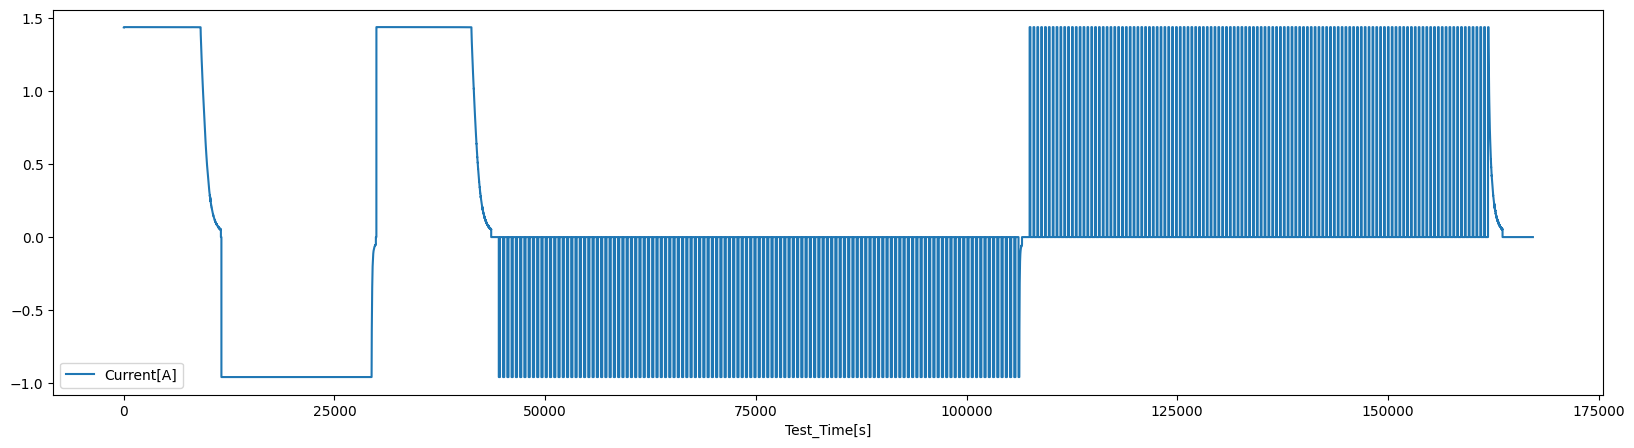

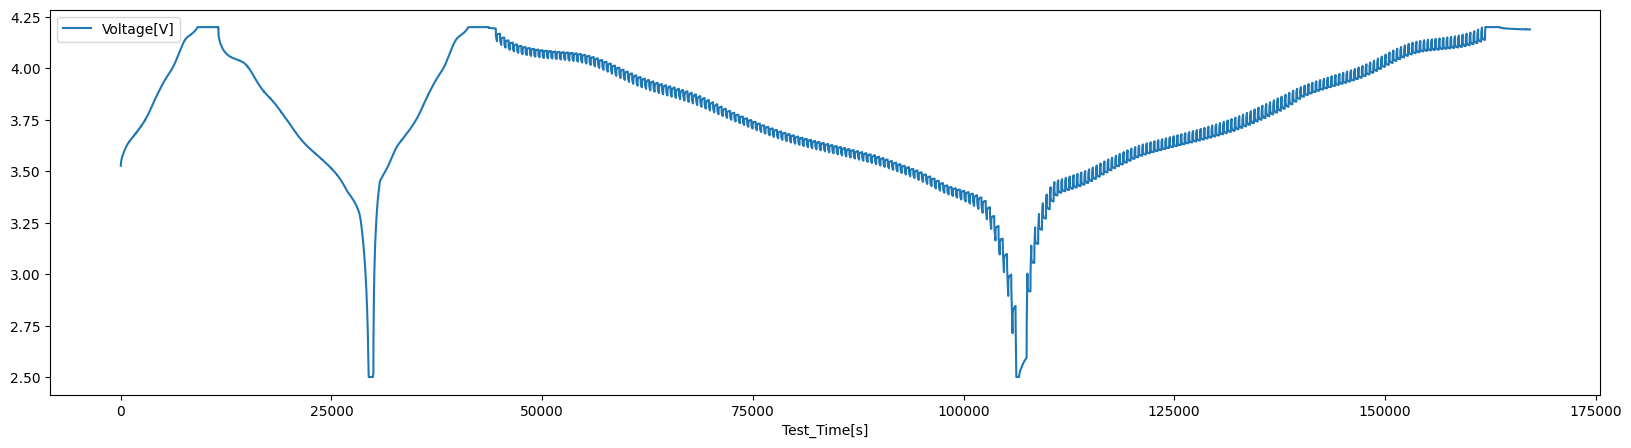

In [10]:
standardized_data.plot(x="Test_Time[s]", y="Current[A]", figsize=(20, 5))
standardized_data.plot(x="Test_Time[s]", y="Voltage[V]", figsize=(20, 5))

<div class="alert alert-block alert-info">
<b>Hint:</b> Use "keep_all_additional_data = True", to keep non standard data logged in your raw data
</div>

In [11]:
standardized_data = eet.read(
    input_path=str(data_folder_path / "Cal_Ageing_Checkup1.xlsx"), config=config, keep_all_additional_data=True
)

In [12]:
standardized_data.head(6)

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],...,Capacity(Ah)_y,Energy(Wh)_y,Power(W),DataPoint - auxVol,Date - auxVol,V1,Aux. ΔV,DataPoint - auxTemp,Date - auxTemp,Aux. ΔT
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,...,0.0000,0.0000,5.0709,1,2024-02-01 10:09:04,0,0,1,2024-02-01 10:09:04,0
1.0,NaN,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,...,0.0004,0.0014,5.0804,2,2024-02-01 10:09:05,0,0,2,2024-02-01 10:09:05,0
2.0,NaN,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,...,0.0008,0.0028,5.0828,3,2024-02-01 10:09:06,0,0,3,2024-02-01 10:09:06,0
3.0,NaN,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,...,0.0012,0.0042,5.0842,4,2024-02-01 10:09:07,0,0,4,2024-02-01 10:09:07,0
4.0,NaN,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,...,0.0016,0.0056,5.0856,5,2024-02-01 10:09:08,0,0,5,2024-02-01 10:09:08,0
5.0,NaN,0,3.5323,1.4401,27.8,5.0,2024-02-01 10:09:09,None,None,None,...,0.0020,0.0071,5.0869,6,2024-02-01 10:09:09,0,0,6,2024-02-01 10:09:09,0


<div class="alert alert-block alert-info">
<b>Hint:</b> Use a path to a folder to convert all compatible files in the folder
</div>

In [13]:
standardized_data_list = eet.read(input_path=str(data_folder_path), config=config)

<Axes: xlabel='Date_Time'>

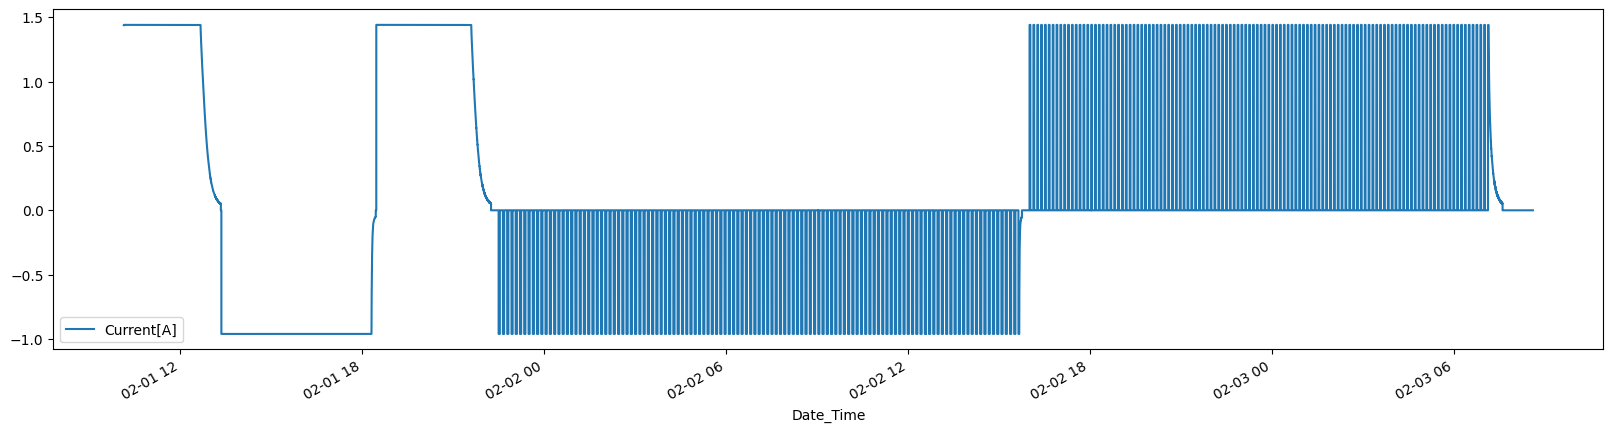

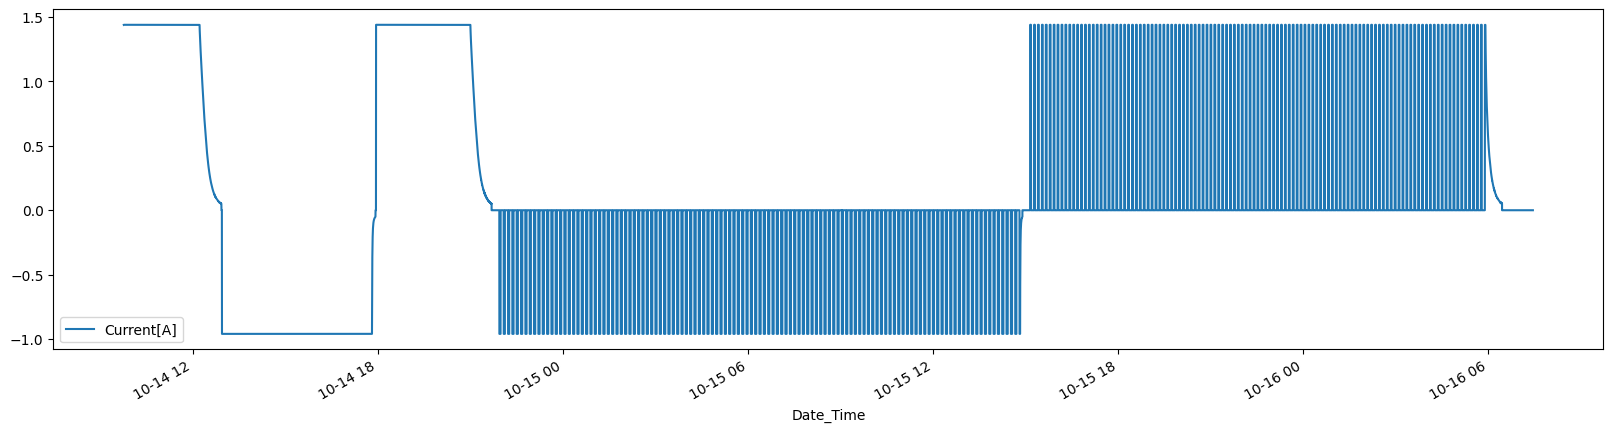

In [14]:
standardized_data_list[0].plot(x="Date_Time", y="Current[A]", figsize=(20, 5))
standardized_data_list[3].plot(x="Date_Time", y="Current[A]", figsize=(20, 5))

<div class="alert alert-block alert-info">
<b>Hint:</b> It is also possible to call read without a config. It will then go alphabetically through all configs and returns the first non failing one.
</div>

<div class="alert alert-block alert-warning">
<b>Warning:</b> Using no config is prone to Errors, so always doublecheck if the correct configs where used.
</div>

In [15]:
data_with_automatically_selected_config = eet.read(input_path=str(data_folder_path))

In [19]:
data_with_automatically_selected_config[0].head(6)

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None
1.0,NaN,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None
2.0,NaN,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None
3.0,NaN,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None
4.0,NaN,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None
5.0,NaN,0,3.5323,1.4401,27.8,5.0,2024-02-01 10:09:09,None,None,None,None
